# This notebook: 
## 1. extracts satellite chlorophyll-a (chl-a) data from ERDDAP using specified coordinates and time windows
## 2. maps chl-a for a selected time
## 3. identifies the month at which the lowest and highest chl value are reached over a yearly cycle at the pixel level
## 4. maps the month value per pixel for the lowest and highest chl level

### Download data

In [1]:
import xarray as xr
import numpy as np
import requests
import os

# 1. Define Coordinates and Time
n_lat, s_lat = 31, 21
e_lon, w_lon = -79.5, -90
start_time = '2003-01-16T00:00:00Z'
end_time = '2025-10-16T00:00:00Z'

# 2. Construct the ERDDAP URL (https://coastwatch.pfeg.noaa.gov/erddap/griddap/erdMH1chlamday_R2022SQ.graph)
# We use f-strings for cleaner string formatting compared to strcat
base_url = "https://coastwatch.pfeg.noaa.gov/erddap/griddap/erdMH1chlamday_R2022SQ.nc"
query = f"?chlor_a[({start_time}):1:({end_time})][({n_lat}):1:({s_lat})][({w_lon}):1:({e_lon})]"
full_url = base_url + query

filename = 'chla_data.nc'
parent_filename = os.path.join('..', filename)

if os.path.exists(filename):
    file_path = filename
    print(f"Found local file {filename}. Skipping download.")
elif os.path.exists(parent_filename):
    file_path = parent_filename
    print(f"Found local file one directory up: {parent_filename}. Skipping download.")
else:
    file_path = filename
    print(f"Downloading data from: {full_url}")
    response = requests.get(full_url, timeout=1200)
    
    if response.status_code == 200:
        with open(file_path, 'wb') as f:
            f.write(response.content)
        print("Download complete.")
    else:
        print(f"Failed to download data. Status code: {response.status_code}")

# 4. Load and Process Data
ds = xr.open_dataset(file_path)

# Extract variables as numpy arrays (similar to ncread)
lat = ds.latitude.values
lon = ds.longitude.values
chla = ds.chlor_a.values
time = ds.time.values

# Python equivalent of [lat1, lon1] = meshgrid(lat, lon)
lon1, lat1 = np.meshgrid(lon, lat)

# View the dataset structure
print(ds)

Found local file one directory up: ../chla_data.nc. Skipping download.
<xarray.Dataset> Size: 66MB
Dimensions:    (time: 271, latitude: 241, longitude: 253)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2003-01-16 2003-02-16 ... 2025-10-16
  * latitude   (latitude) float32 964B 31.02 30.98 30.94 ... 21.1 21.06 21.02
  * longitude  (longitude) float32 1kB -90.02 -89.98 -89.94 ... -79.56 -79.52
Data variables:
    chlor_a    (time, latitude, longitude) float32 66MB nan nan ... 0.1075
Attributes: (12/52)
    _lastModified:                     2025-12-10T00:25:19.000Z
    cdm_data_type:                     Grid
    Conventions:                       CF-1.6 ACDD-1.3, COARDS
    creator_email:                     data@oceancolor.gsfc.nasa.gov
    creator_name:                      NASA/GSFC/OBPG
    creator_type:                      group
    ...                                ...
    summary:                           Moderate Resolution Imaging Spectrorad...
    temporal_range:   

### Map chl-a for a selected month and year

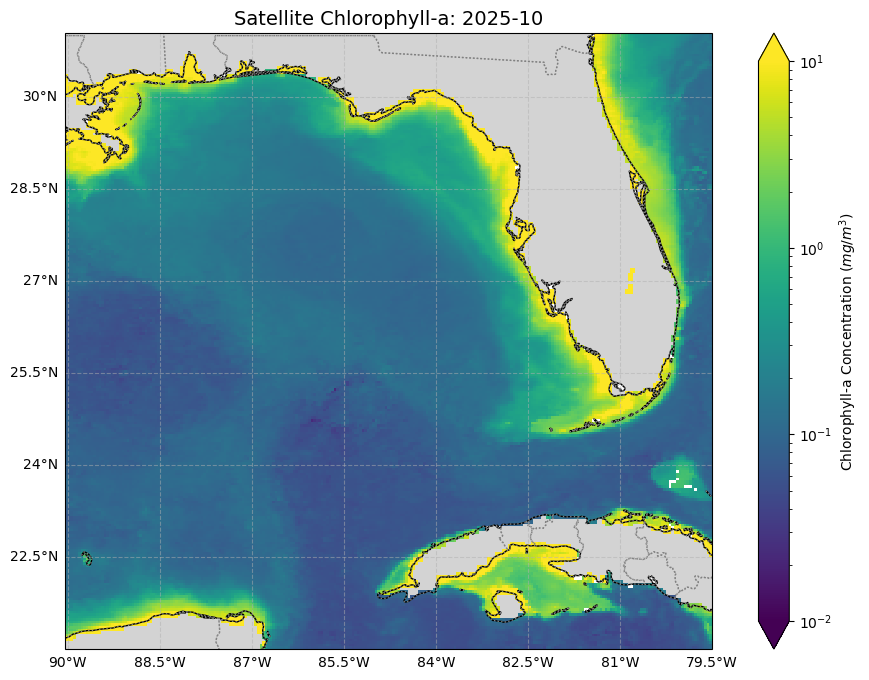

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm

# 1. Select the specific time slice
# Example: Select January 2015. 
# You can use a string 'YYYY-MM' with xarray's .sel() method
target_time = '2025-10'
data_slice = ds.chlor_a.sel(time=target_time, method='nearest')

# 2. Setup the map projection
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# 3. Plot the data
# We use LogNorm because Chl-a values are typically log-distributed
im = ax.pcolormesh(ds.longitude, ds.latitude, data_slice,
                   transform=ccrs.PlateCarree(),
                   cmap='viridis', 
                   norm=LogNorm(vmin=0.01, vmax=10))

# 4. Add geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray')
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# 5. Add gridlines and labels
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# 6. Add Colorbar and Labels
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.05, extend='both')
cbar.set_label('Chlorophyll-a Concentration ($mg/m^3$)')

plt.title(f'Satellite Chlorophyll-a: {target_time}', fontsize=14)
# plt.savefig()
plt.show()

### To find the month when the seasonal peak occurs for every pixel, we need to perform these steps:
###  1. Group the data by month.
###  2. Calculate the climatological mean (the "average" year) to smooth out episodic events (like hurricanes or odd blooms).
###  3. Find the index (month) where the maximum value occurs for every latitude/longitude point.

Found local file one directory up: ../topo_data.nc. Skipping download.


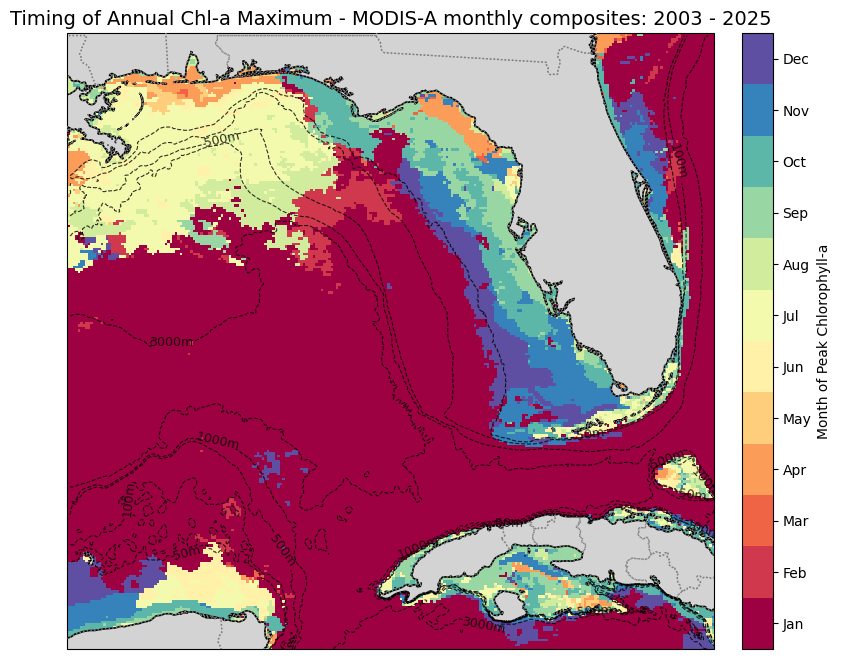

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import numpy as np
import requests
import os

# --- 1. Calculate the Chl-a Peak Month ---
climatology = ds.chlor_a.groupby('time.month').mean(dim='time')
peak_month = climatology.idxmax(dim='month').load()
trough_month = climatology.idxmin(dim='month').load()

# --- 2. Download Bathymetry Data (ETOPO) ---
topo_filename = 'topo_data.nc'
parent_topo_filename = os.path.join('..', topo_filename)

topo_url = (
    f"https://coastwatch.pfeg.noaa.gov/erddap/griddap/etopo180.nc?altitude"
    f"[({min(s_lat, n_lat)}):1:({max(s_lat, n_lat)})]"
    f"[({min(w_lon, e_lon)}):1:({max(w_lon, e_lon)})]"
)

if os.path.exists(topo_filename):
    topo_filename = topo_filename
    print(f"Found local file {topo_filename}. Skipping download.")
elif os.path.exists(parent_topo_filename):
    topo_filename = parent_topo_filename
    print(f"Found local file one directory up: {topo_filename}. Skipping download.")
else:
    topo_filename = topo_filename
    print(f"Attempting to download bathymetry from: {topo_url}")
    try:
        r = requests.get(topo_url, timeout=120)
        if r.status_code == 200:
            with open(topo_filename, 'wb') as f:
                f.write(r.content)
            print("Bathymetry download complete.")
        else:
            print(f"Download failed with status {r.status_code}. Using fallback method...")
            topo_ds = None
    except Exception as e:
        print(f"Error occurred: {e}")
        topo_ds = None

# --- 3. Load Data and Setup Plot ---
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
cmap = plt.get_cmap('Spectral', 12)

# --- 4. Plot Chl-a Peak Month (use peak_month or trough_month) ---
im = ax.pcolormesh(ds.longitude, ds.latitude, peak_month,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap, vmin=0.5, vmax=12.5, zorder=1)

# --- 5. Add Bathymetry Contours (If download succeeded) ---
if os.path.exists(topo_filename):
    topo_ds = xr.open_dataset(topo_filename)
    # ETOPO uses 'latitude'/'longitude' names
    # Ensure levels match ocean depths (negative)
    levels = [-5000, -3000, -1000, -500, -100, -50]
    
    contours = ax.contour(topo_ds.longitude, topo_ds.latitude, topo_ds.altitude, 
                           levels=levels, colors='black', 
                           linewidths=0.8, alpha=0.8, 
                           transform=ccrs.PlateCarree(), zorder=4)

    plt.clabel(contours, inline=True, fontsize=9, fmt={lev: f'{int(abs(lev))}m' for lev in levels})

# --- 6. Add Geographic Features ---
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=3)
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray', zorder=3)

# --- 7. Formatting ---
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, ticks=range(1, 13))
cbar.set_ticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
cbar.set_label('Month of Peak Chlorophyll-a')

plt.title('Timing of Annual Chl-a Maximum - MODIS-A monthly composites: 2003 - 2025', fontsize=14)
# plt.savefig()
plt.show()

### Seasonal Chl-a Curves by Peak-Month Group

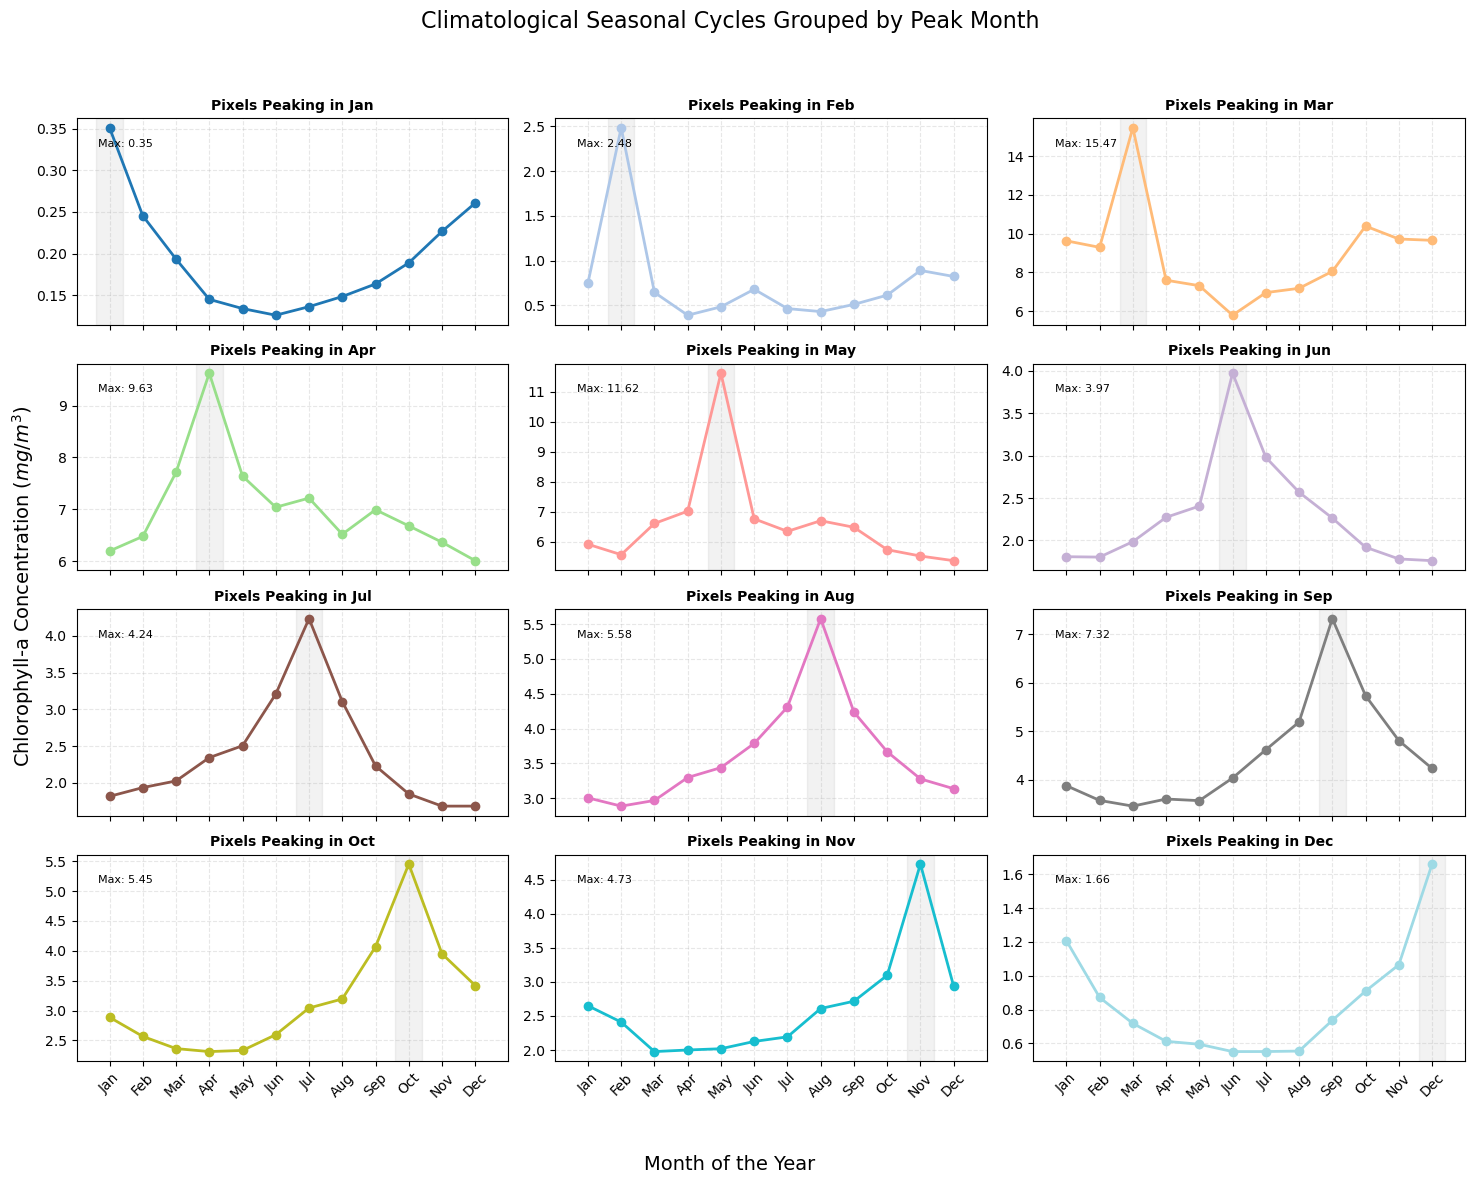

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the Monthly Climatology
climatology = ds.chlor_a.groupby('time.month').mean(dim='time').load()

# 2. Setup the figure for 12 subplots
# Changed sharey to False so each plot scales to its own max/min
fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=False)
axes = axes.flatten()
months_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
x_axis = np.arange(1, 13)

# 3. Use 'tab20' to stay consistent with the discrete map colors
cmap = plt.get_cmap('tab20', 12)

for i in range(12):
    month_id = i + 1
    ax = axes[i]
    
    # Mask pixels that peak in this specific month
    mask = (peak_month == month_id)
    
    # Check if there are any pixels in this group to avoid Mean-of-Empty-Slice warnings
    if mask.any():
        group_curve = climatology.where(mask).mean(dim=['latitude', 'longitude'])
        
        # Plot the curve
        ax.plot(x_axis, group_curve, marker='o', color=cmap(i), linewidth=2)
        
        # Set titles and formatting
        ax.set_title(f'Pixels Peaking in {months_labels[i]}', fontsize=10, fontweight='bold')
        ax.grid(alpha=0.3, linestyle='--')
        
        # Highlight the peak month
        ax.axvspan(month_id - 0.4, month_id + 0.4, color='gray', alpha=0.1)
        
        # Add the specific max/min values to the plot as text for context
        ax.text(0.05, 0.9, f"Max: {group_curve.max().values:.2f}", 
                transform=ax.transAxes, fontsize=8, verticalalignment='top')
    else:
        ax.text(0.5, 0.5, 'No pixels in this group', ha='center', va='center')
        ax.set_title(f'Pixels Peaking in {months_labels[i]}', fontsize=10)

# 4. Global formatting
# Set ticks for the bottom row
for ax in axes[-3:]:
    ax.set_xticks(x_axis)
    ax.set_xticklabels(months_labels, rotation=45)

fig.supxlabel('Month of the Year', fontsize=14)
fig.supylabel('Chlorophyll-a Concentration ($mg/m^3$)', fontsize=14)
fig.suptitle('Climatological Seasonal Cycles Grouped by Peak Month', fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Depth-Based Climatology Analysis

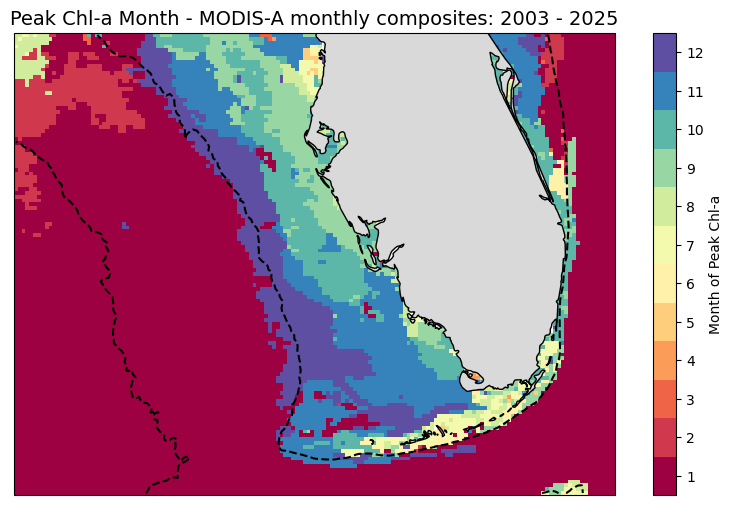

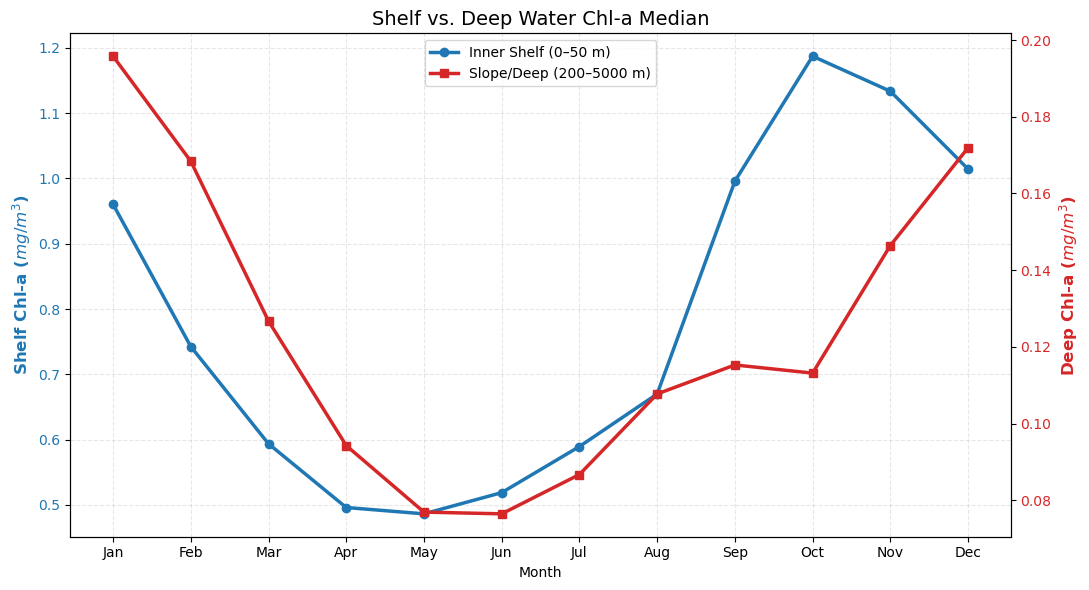

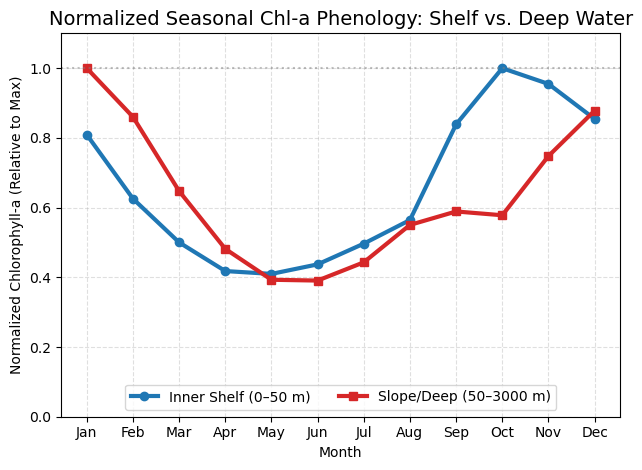

In [5]:
# --- 1. Subset the existing dataset locally ---
n_lat_sub, s_lat_sub = 29.0, 24.0
e_lon_sub, w_lon_sub = -79.5, -86.0

ds_sub = ds.sel(latitude=slice(n_lat_sub, s_lat_sub), 
                longitude=slice(w_lon_sub, e_lon_sub))

# --- 2. Generate the Peak Month Map ---
climatology_sub = ds_sub.chlor_a.groupby('time.month').mean(dim='time').load()
peak_month_sub = climatology_sub.idxmax(dim='month').load()

# Interpolate topography to the Chl-a grid for masking
topo_interp = topo_ds.altitude.interp(latitude=ds_sub.latitude, 
                                      longitude=ds_sub.longitude, method='linear')

plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
cmap = plt.get_cmap('Spectral', 12)

im = ax.pcolormesh(ds_sub.longitude, ds_sub.latitude, peak_month_sub,
                   transform=ccrs.PlateCarree(), cmap=cmap, vmin=0.5, vmax=12.5)

# Add 50m and 3000m contours
ax.contour(ds_sub.longitude, ds_sub.latitude, topo_interp, 
           levels=[-3000, -50], colors='black', linewidths=1.5, alpha=1, zorder=4)

ax.add_feature(cfeature.LAND, facecolor='#d9d9d9', zorder=2)
ax.add_feature(cfeature.COASTLINE, zorder=3)
plt.colorbar(im, ax=ax, ticks=range(1, 13), label='Month of Peak Chl-a')
plt.title(f'Peak Chl-a Month - MODIS-A monthly composites: 2003 - 2025', fontsize=14)
plt.show()

# --- 3. Calculate Mean Chl-a by Depth Range ---
mask_shallow = (topo_interp <= 0) & (topo_interp >= -50)
mask_deep = (topo_interp < -200) & (topo_interp >= -5000)

shelf_mean = climatology_sub.where(mask_shallow).median(dim=['latitude', 'longitude'])
deep_mean = climatology_sub.where(mask_deep).median(dim=['latitude', 'longitude'])

# Normalization: Value / Max Value
shelf_norm = shelf_mean / shelf_mean.max()
deep_norm = deep_mean / deep_mean.max()

# --- 4. Plot Seasonal Curves with Dual Y-Axes ---
fig, ax1 = plt.subplots(figsize=(11, 6))

# 1. Define the roll amount
# Original: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] (Oct is index 9)
# To center index 9 in a 12-element array (target center index 5 or 6), 
# we shift by 4 months.
shift = 4

months = np.arange(1, 13)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Left Axis: Inner Shelf
color_shelf = '#1f77b4'
lns1 = ax1.plot(months, shelf_mean, 'o-', color=color_shelf, linewidth=2.5, label='Inner Shelf (0–50 m)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Shelf Chl-a ($mg/m^3$)', color=color_shelf, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_shelf)
ax1.grid(True, linestyle='--', alpha=0.3)

# Right Axis: Deep Water
ax2 = ax1.twinx()  # Create the second axis
color_deep = '#d62728'
lns2 = ax2.plot(months, deep_mean, 's-', color=color_deep, linewidth=2.5, label='Slope/Deep (200–5000 m)')
ax2.set_ylabel('Deep Chl-a ($mg/m^3$)', color=color_deep, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_deep)

# Combine legends from both axes
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper center', frameon=True)

plt.xticks(months, month_names)
plt.title('Shelf vs. Deep Water Chl-a Median', fontsize=14)
fig.tight_layout()
plt.show()

plt.plot(months, shelf_norm, 'o-', color='#1f77b4', linewidth=3, label='Inner Shelf (0–50 m)')
plt.plot(months, deep_norm, 's-', color='#d62728', linewidth=3, label='Slope/Deep (50–3000 m)')

# Reference line at 1.0
plt.axhline(1.0, color='gray', linestyle=':', alpha=0.5)

plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(months, month_names)
plt.ylabel('Normalized Chlorophyll-a (Relative to Max)')
plt.xlabel('Month')
plt.title('Normalized Seasonal Chl-a Phenology: Shelf vs. Deep Water', fontsize=14)
plt.ylim(0, 1.1) # Set limits to focus on the shape
plt.legend(frameon=True, loc='lower center', ncol=2)

plt.tight_layout()
plt.show()

### Fetching SSS and Running the Phenology Analysis 

In [ ]:
import copernicusmarine

# 1. Credentials
# If it's your first time, it will prompt for your Copernicus username/password
# Or use: 

copernicusmarine.login() 

# 2. Subset and Open the Dataset
# We use the dataset ID from your link: cmems_obs-mob_glo_phy-sss_my_multi_P1M_202311
ds_sss = copernicusmarine.open_dataset(
    dataset_id="cmems_obs-mob_glo_phy-sss_my_multi_P1M",
    minimum_longitude=w_lon_sub,
    maximum_longitude=e_lon_sub,
    minimum_latitude=s_lat_sub,
    maximum_latitude=n_lat_sub,
    start_datetime="2003-01-16T00:00:00",
    end_datetime="2022-12-16T00:00:00", # Multi-observation MY usually lags a bit
    variables=["sos"] # 'sos' is the standard name for Sea Surface Salinity
)

### Map and plot SSS data

In [ ]:
# Calculate Salinity Phenology (Peak Month)
# Note: For salinity, the 'peak' might be the minimum (freshwater pulse) 
# or maximum. Here we follow your max logic.
climatology_sss = ds_sss.sos.groupby('time.month').mean(dim='time').squeeze().load()
trough_month_sss = climatology_sss.idxmin(dim='month').squeeze().load()

# 4. Depth Masking (Using the topo_interp from your previous cell)
# We interpolate the bathymetry to the SSS grid
topo_sss = topo_ds.altitude.interp(latitude=ds_sss.latitude, 
                                   longitude=ds_sss.longitude, method='linear')

# Setup the Plot using Object-Oriented style
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

cmap = plt.get_cmap('Spectral', 12)

# Plot SSS Trough Month
# We use trough_month_sss.values to ensure matplotlib gets a pure numpy array
im = ax.pcolormesh(ds_sss.longitude, ds_sss.latitude, trough_month_sss.values,
                   transform=ccrs.PlateCarree(), 
                   cmap=cmap, 
                   vmin=0.5, vmax=12.5,
                   shading='auto')

# Add Isobaths
# We explicitly state the transform for the contour as well
ax.contour(ds_sss.longitude, ds_sss.latitude, topo_sss.values, 
           levels=[-3000, -50], colors='black', linewidths=1.5, 
           transform=ccrs.PlateCarree(), zorder=4)

# Add geographic features
ax.add_feature(cfeature.LAND, facecolor='#d9d9d9', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=3)
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray', zorder=3)

# Formatting Colorbar - Note the use of fig.colorbar(im, ax=ax)
cbar = fig.colorbar(im, ax=ax, ticks=range(1, 13), pad=0.03, shrink=0.7)
cbar.set_ticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
cbar.set_label('Month of Minimum Sea Surface Salinity', fontsize=12)

ax.set_title('Minimum SSS Month (2003-2022)', fontsize=14)
plt.show()

mask_0_50 = (topo_sss <= 0) & (topo_sss >= -50)
mask_50_3000 = (topo_sss < -50) & (topo_sss >= -3000)

shelf_sss = climatology_sss.where(mask_0_50).mean(dim=['latitude', 'longitude'])
deep_sss = climatology_sss.where(mask_50_3000).mean(dim=['latitude', 'longitude'])

# Plot Comparison
plt.figure(figsize=(11, 6))
months = np.arange(1, 13)
plt.plot(months, shelf_sss, 'o-', label='Shelf SSS (< 50m)', color='teal')
plt.plot(months, deep_sss, 's-', label='Deep SSS (> 50m)', color='darkorange')
plt.xticks(months, ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Shelf vs. Deep SSS (2003-2022)')
plt.legend()
plt.show()

### Map SSS for a selected climatological month

In [ ]:
# 1. Select November (Month 11) from the climatology
# Climatology was grouped by month, so we select month=11
sss_nov = climatology_sss.sel(month=11).squeeze()

# 2. Setup the Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# 3. Plot SSS Data
# We use a sequential colormap. 'viridis' or 'YlGnBu_r' are great for salinity.
# vmin/vmax should be tuned to your region (e.g., 30 to 37 for GoM)
im = ax.pcolormesh(sss_nov.longitude, sss_nov.latitude, sss_nov.values,
                   transform=ccrs.PlateCarree(),
                   cmap='YlGnBu_r',
                   vmin=34, 
                   vmax=36, 
                   shading='auto')

# 4. Add Isobaths (50m and 3000m)
if 'topo_sss' in locals():
    ax.contour(ds_sss.longitude, ds_sss.latitude, topo_sss.values, 
               levels=[-3000, -50], colors='black', linewidths=1.2, 
               transform=ccrs.PlateCarree(), zorder=4)

# 5. Add Geographic Features
ax.add_feature(cfeature.LAND, facecolor='#d9d9d9', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=3)
ax.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.5, zorder=3)

# 6. Formatting
cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7)
cbar.set_label('Sea Surface Salinity (psu)', fontsize=12)

ax.set_title('Climatological Sea Surface Salinity: November', fontsize=14)

plt.show()

# Download or Load Fluorescence (nFLH) Data


In [9]:
# Download nFLH (fluorescence) data
import xarray as xr
import numpy as np
import requests
import os

# 1. Define Coordinates and Time (Same as first cell)
n_lat, s_lat = 31, 21
e_lon, w_lon = -79.5, -90
start_time = '2003-01-16T00:00:00Z'
end_time = '2025-10-16T00:00:00Z'

# 2. Construct the ERDDAP URL for erdMH1cflhmday_R2022SQ
base_url = "https://coastwatch.pfeg.noaa.gov/erddap/griddap/erdMH1cflhmday_R2022SQ.nc"
query = f"?nflh[({start_time}):1:({end_time})][({n_lat}):1:({s_lat})][({w_lon}):1:({e_lon})]"
full_url = base_url + query

# 3. Path Management - Use a single consistent location
filename = 'nflh_data.nc'
parent_filename = os.path.join('..', filename)

if os.path.exists(filename):
    file_path = filename
    print(f"Found local file {filename}. Skipping download.")
elif os.path.exists(parent_filename):
    file_path = parent_filename
    print(f"Found local file one directory up: {parent_filename}. Skipping download.")
else:
    file_path = filename
    print(f"Downloading nFLH data from: {full_url}")
    try:
        with requests.get(full_url, stream=True, timeout=1800) as r:
            r.raise_for_status()
            with open(file_path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
        print("Download complete.")
    except Exception as e:
        print(f"Download failed: {e}")

# Ensure the later open_dataset uses the resolved path
filename = file_path

# 4. Load Data
ds_nflh = xr.open_dataset(filename)
print(ds_nflh)


Found local file one directory up: ../nflh_data.nc. Skipping download.
<xarray.Dataset> Size: 66MB
Dimensions:    (time: 270, latitude: 241, longitude: 253)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2003-01-05 2003-02-05 ... 2025-10-05
  * latitude   (latitude) float32 964B 31.02 30.98 30.94 ... 21.1 21.06 21.02
  * longitude  (longitude) float32 1kB -90.02 -89.98 -89.94 ... -79.56 -79.52
Data variables:
    nflh       (time, latitude, longitude) float32 66MB ...
Attributes: (12/52)
    _lastModified:                     2025-12-10T00:26:07.000Z
    cdm_data_type:                     Grid
    Conventions:                       CF-1.6 ACDD-1.3, COARDS
    creator_email:                     data@oceancolor.gsfc.nasa.gov
    creator_name:                      NASA/GSFC/OBPG
    creator_type:                      group
    ...                                ...
    summary:                           Moderate Resolution Imaging Spectrorad...
    temporal_range:                  

# This cell computes a fluorescence analysis

# Baseline Fluorescence (nFLH) Map for a Selected Month

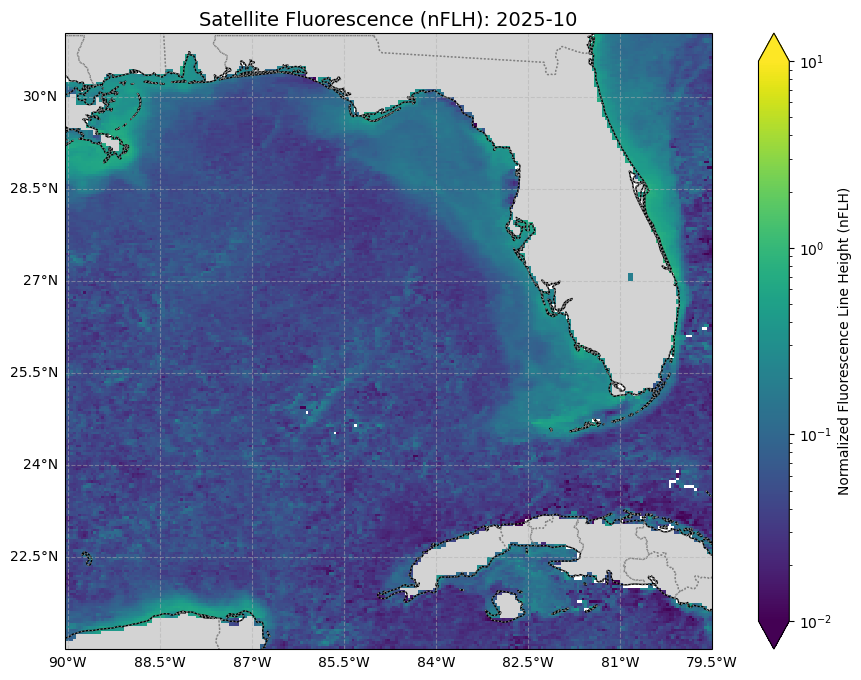

In [10]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm

# 1. Select the specific time slice
target_time = '2025-10'
data_slice_nflh = ds_nflh.nflh.sel(time=target_time, method='nearest')

# 2. Setup the map projection
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# 3. Plot the data
im = ax.pcolormesh(ds_nflh.longitude, ds_nflh.latitude, data_slice_nflh,
                   transform=ccrs.PlateCarree(),
                   cmap='viridis', 
                   norm=LogNorm(vmin=0.01, vmax=10))

# 4. Add geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray')
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# 5. Add gridlines and labels
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# 6. Add Colorbar and Labels
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.05, extend='both')
cbar.set_label('Normalized Fluorescence Line Height (nFLH)')

plt.title(f'Satellite Fluorescence (nFLH): {target_time}', fontsize=14)
# plt.savefig()
plt.show()

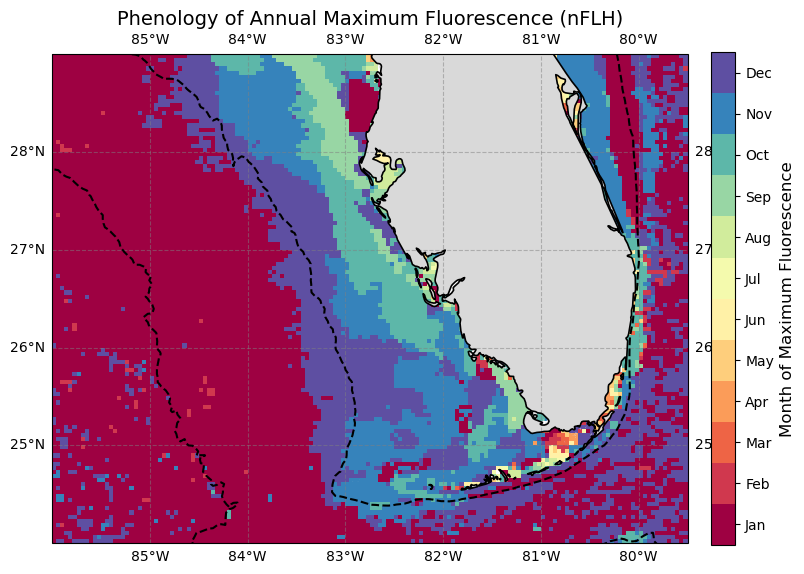

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import matplotlib.colors as mcolors

# 1. Calculate climatology (monthly means)
nflh_climatology = ds_nflh.nflh.groupby('time.month').mean(dim='time')

# 2. Calculate the month of maximum fluorescence
# idxmax returns the actual month (1-12) of the maximum value along the 'month' dimension
max_nflh_month = nflh_climatology.idxmax(dim='month')

# 3. Plotting the map
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# --- Modified Extents ---
n_lat_sub, s_lat_sub = 29.0, 24.0
e_lon_sub, w_lon_sub = -79.5, -86.0
ax.set_extent([w_lon_sub, e_lon_sub, s_lat_sub, n_lat_sub], crs=ccrs.PlateCarree())

# Define colormap for months (1-12)
cmap = plt.get_cmap('Spectral', 12)

# Plot the data
im = ax.pcolormesh(max_nflh_month.longitude, max_nflh_month.latitude, max_nflh_month.values,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap, vmin=0.5, vmax=12.5)

# Add bathymetric contours
if 'topo_ds' in locals() or 'topo_ds' in globals():
    topo_nflh = topo_ds.altitude.interp(latitude=ds_nflh.latitude, 
                                        longitude=ds_nflh.longitude, method='linear')
    ax.contour(ds_nflh.longitude, ds_nflh.latitude, topo_nflh.values, 
               levels=[-3000, -50], colors='black', linewidths=1.5, 
               transform=ccrs.PlateCarree(), zorder=4)

# Add features
ax.add_feature(cfeature.LAND, facecolor='#d9d9d9', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=3)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', color='gray', alpha=0.5)

# Colorbar formatting
cbar = fig.colorbar(im, ax=ax, ticks=np.arange(1, 13), orientation='vertical', pad=0.03, shrink=0.8)
cbar.set_ticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
cbar.set_label('Month of Maximum Fluorescence', fontsize=12)

ax.set_title('Phenology of Annual Maximum Fluorescence (nFLH)', fontsize=14)

plt.show()

# nFLH Climatology Phenology (Shelf vs. Deep Water)


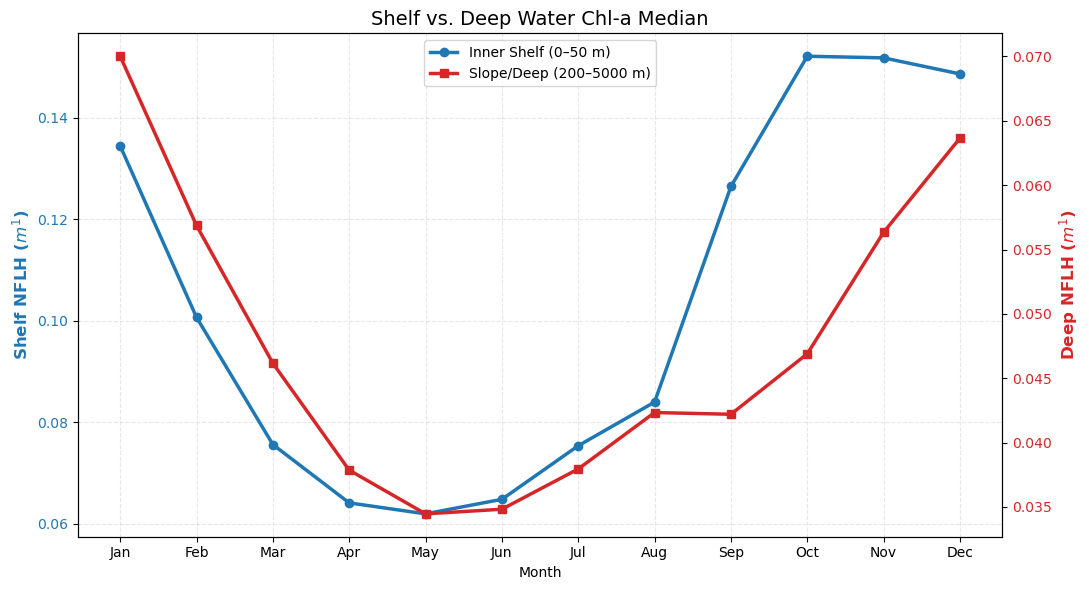

In [12]:
# --- Calculate Mean Chl-a by Depth Range ---
mask_nflh_shallow = (topo_interp <= 0) & (topo_interp >= -50)
mask_nflh_deep = (topo_interp < -200) & (topo_interp >= -5000)

shelf_mean = nflh_climatology.where(mask_nflh_shallow).median(dim=['latitude', 'longitude'])
deep_mean = nflh_climatology.where(mask_nflh_deep).median(dim=['latitude', 'longitude'])

# --- Plot Seasonal Curves with Dual Y-Axes ---
fig, ax1 = plt.subplots(figsize=(11, 6))

months = np.arange(1, 13)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Left Axis: Inner Shelf
color_shelf = '#1f77b4'
lns1 = ax1.plot(months, shelf_mean, 'o-', color=color_shelf, linewidth=2.5, label='Inner Shelf (0–50 m)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Shelf NFLH ($m^1$)', color=color_shelf, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_shelf)
ax1.grid(True, linestyle='--', alpha=0.3)

# Right Axis: Deep Water
ax2 = ax1.twinx()  # Create the second axis
color_deep = '#d62728'
lns2 = ax2.plot(months, deep_mean, 's-', color=color_deep, linewidth=2.5, label='Slope/Deep (200–5000 m)')
ax2.set_ylabel('Deep NFLH ($m^1$)', color=color_deep, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_deep)

# Combine legends from both axes
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper center', frameon=True)

plt.xticks(months, month_names)
plt.title('Shelf vs. Deep Water Chl-a Median', fontsize=14)
fig.tight_layout()
plt.show()

### Load SFER cruise data and calculate climatological monthly means, and plot the data

Total years in record: 12
Months passing 50.0% threshold: [1, 3, 5, 7, 8, 10, 12]


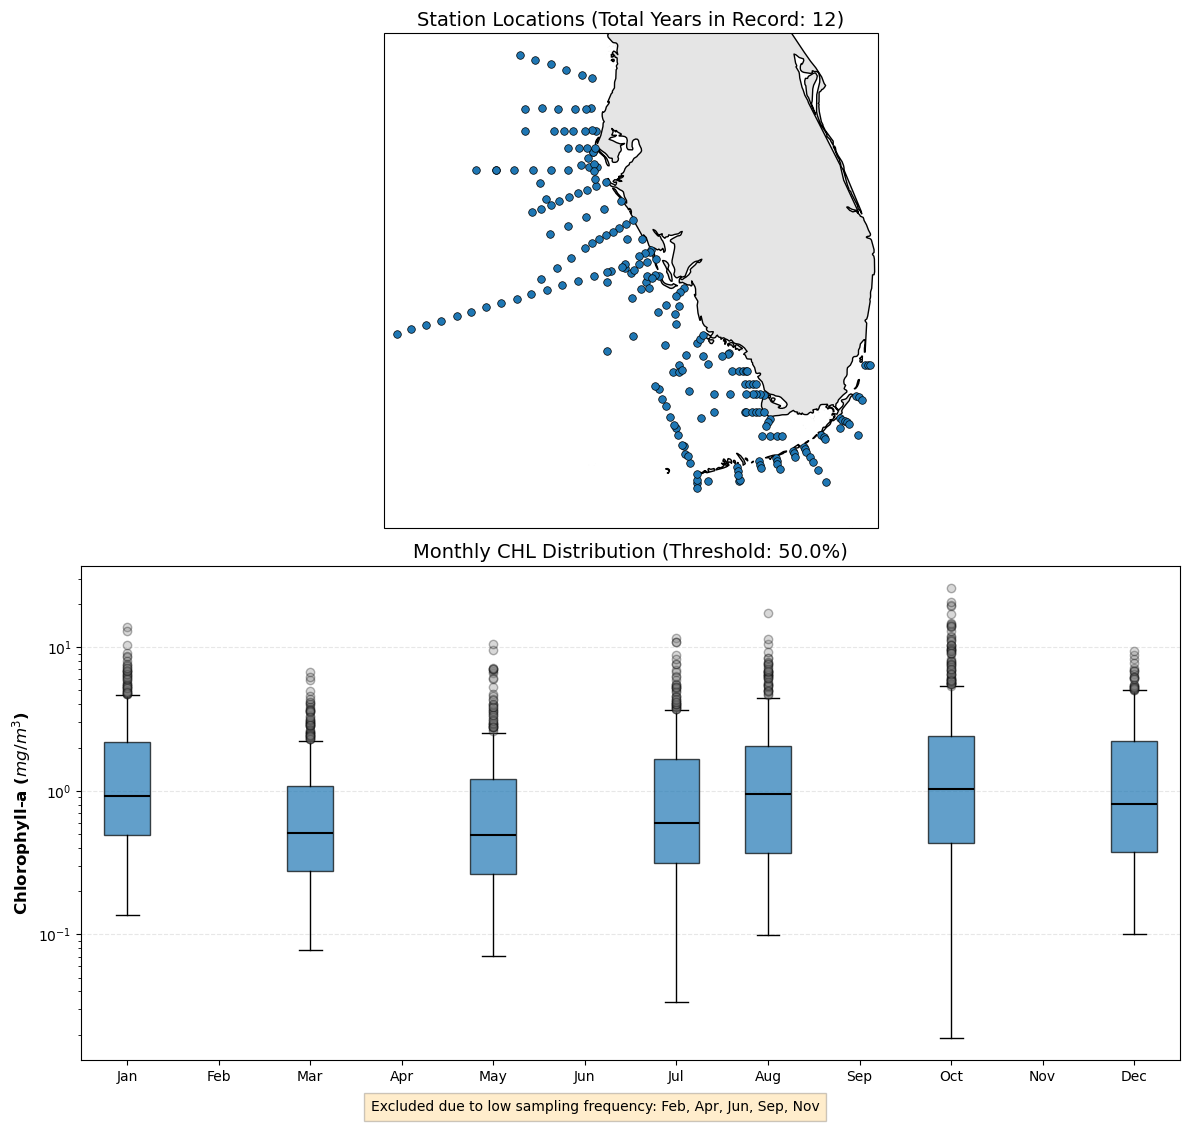

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- 1. SETTINGS & PARAMETERS ---
sampling_threshold = 0.5  # Only use months sampled in >= 50% of all years
param_to_plot = 'chl'     # Parameter for the boxplot
lat_min, lat_max = 24, 29
lon_min, lon_max = -85.0, -80.0
depth_classes = ['Surface'] # add 'Mid', 'Bottom' if you want to include those as well

# --- 2. DATA LOADING & SPATIAL SUBSETTING ---
df = pd.read_csv('/home/enrique.montes@CNS.local/plankton_imaging/SFER_data.csv', low_memory=False)

df_sub = df[
    (df['lat_dec'] >= lat_min) & (df['lat_dec'] <= lat_max) & 
    (df['lon_dec'] >= lon_min) & (df['lon_dec'] <= lon_max) &
    (df['depth_class'].isin(depth_classes))
].copy()

# Ensure numeric types
df_sub[param_to_plot] = pd.to_numeric(df_sub[param_to_plot], errors='coerce')
df_sub['year'] = pd.to_numeric(df_sub['year'], errors='coerce')

# --- 3. FREQUENCY FILTER LOGIC ---
# Calculate total unique years in the spatial subset
total_unique_years = df_sub['year'].nunique()

# Count unique years sampled for each month
years_per_month = df_sub.groupby('month')['year'].nunique()
sampling_freq = years_per_month / total_unique_years

# Identify valid months based on the threshold
valid_months_idx = sampling_freq[sampling_freq >= sampling_threshold].index.tolist()

print(f"Total years in record: {total_unique_years}")
print(f"Months passing {sampling_threshold*100}% threshold: {valid_months_idx}")

# Filter the plotting dataframe to include only valid months
df_filtered = df_sub[df_sub['month'].isin(valid_months_idx)].dropna(subset=[param_to_plot])

# --- 4. PREPARE PLOTTING DATA ---
months_full_range = range(1, 13)
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Create a list of data arrays for the boxplot (Empty array for filtered-out months)
data_by_month = []
for m in months_full_range:
    if m in valid_months_idx:
        data_by_month.append(df_filtered[df_filtered['month'] == m][param_to_plot].values)
    else:
        data_by_month.append(np.array([])) # Placeholder for skipped months

# --- 5. VISUALIZATION ---
fig = plt.figure(figsize=(12, 12))
theme_color = '#1f77b4'

# PANEL A: Map of Stations
ax_map = fig.add_subplot(2, 1, 1, projection=ccrs.PlateCarree())
ax_map.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax_map.add_feature(cfeature.LAND, facecolor='#e5e5e5', zorder=1)
ax_map.add_feature(cfeature.COASTLINE, linewidth=1, zorder=2)

unique_stations = df_sub.groupby('station').first().reset_index()
ax_map.scatter(unique_stations['lon_dec'], unique_stations['lat_dec'], color=theme_color, 
               s=30, transform=ccrs.PlateCarree(), edgecolors='k', linewidth=0.5, zorder=3)
ax_map.set_title(f'Station Locations (Total Years in Record: {total_unique_years})', fontsize=14)

# PANEL B: Frequency-Filtered Boxplot
ax_box = fig.add_subplot(2, 1, 2)

# Remove non-positive values for log-scale plotting
log_data_by_month = [arr[arr > 0] if len(arr) else arr for arr in data_by_month]

bp = ax_box.boxplot(log_data_by_month, positions=np.arange(1, 13), patch_artist=True,
                    showfliers=True,
                    medianprops={'color': 'black', 'linewidth': 1.5},
                    boxprops={'facecolor': theme_color, 'alpha': 0.7},
                    flierprops={'marker': 'o', 'markerfacecolor': 'gray', 'alpha': 0.3})

ax_box.set_yscale('log')
ax_box.set_ylabel(f'Chlorophyll-a ($mg/m^3$)', fontsize=12, fontweight='bold')
ax_box.set_xticks(np.arange(1, 13))
ax_box.set_xticklabels(month_labels)
# ax_box.set_ylim(0.1, 10)
ax_box.grid(True, axis='y', linestyle='--', alpha=0.3)

# Add a text annotation showing the excluded months
excluded = sorted(list(set(range(1, 13)) - set(valid_months_idx)))
excluded_names = [month_labels[m-1] for m in excluded]
plt.title(f'Monthly {param_to_plot.upper()} Distribution (Threshold: {sampling_threshold*100}%)', fontsize=14)
plt.figtext(0.5, 0.02, f"Excluded due to low sampling frequency: {', '.join(excluded_names)}", 
            ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Map the month for climatological maximum (or minimum) of a selected parameter observed at SFER sites

Total stations: 214
Eligible stations: 108
Months passing 30.0% threshold: [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


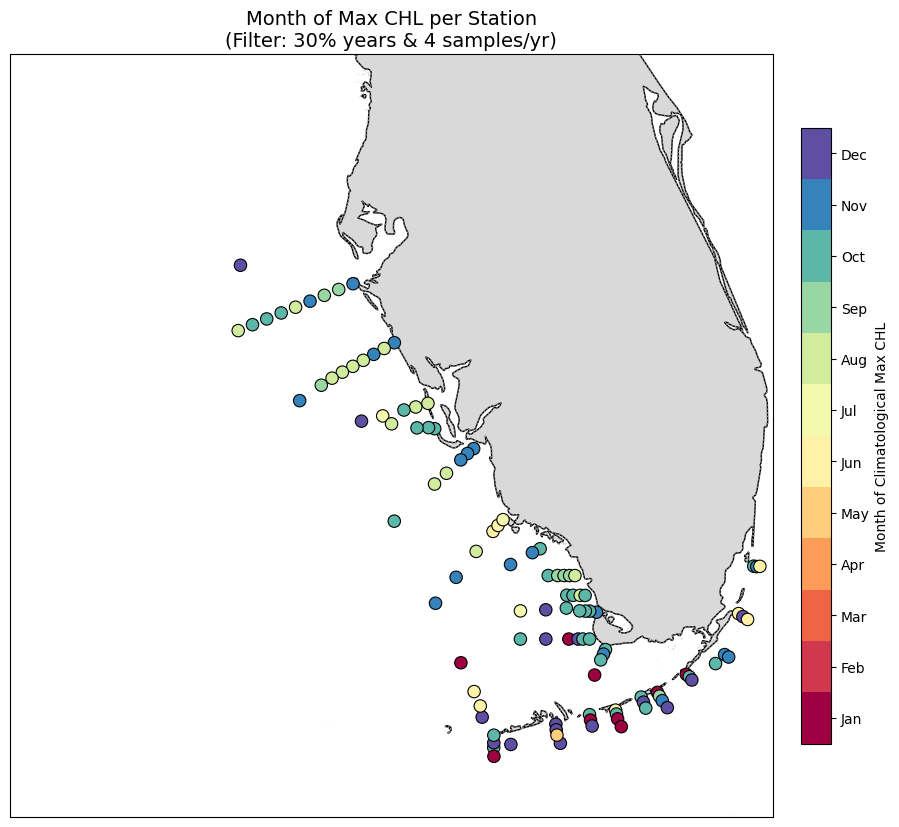

/tmp/ipykernel_3854569/1817833986.py:118: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_boxplot, labels=months_labels, patch_artist=True,


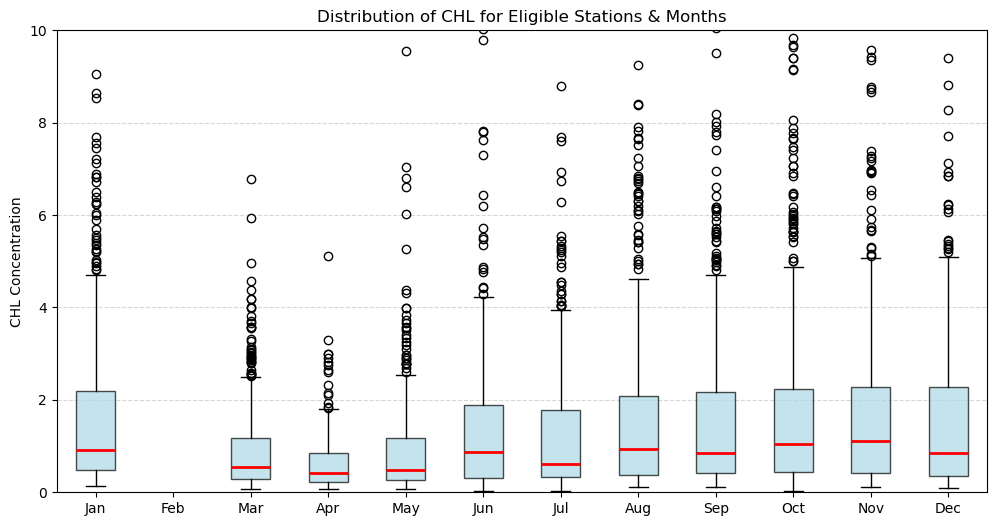

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- 1. SETTINGS & PARAMETERS ---
target_param = 'chl'            
analysis_type = 'max'           
year_threshold = 0.3            
min_samples_per_year = 4        
lat_min, lat_max = 24, 29
lon_min, lon_max = -85.0, -80.0

# --- 2. DATA PREPARATION ---
df_sub = df[
    (df['lat_dec'] >= lat_min) & (df['lat_dec'] <= lat_max) & 
    (df['lon_dec'] >= lon_min) & (df['lon_dec'] <= lon_max) &
    (df['depth_class'].isin(['Surface'])) 
].copy()

df_sub[target_param] = pd.to_numeric(df_sub[target_param], errors='coerce')
df_sub = df_sub.dropna(subset=[target_param])

# --- 3. TEMPORAL FILTERING (STATION LEVEL) ---
total_years_in_record = df_sub['year'].nunique()

station_stats = df_sub.groupby('station').agg({
    'year': 'nunique',           
    'month': 'count',            
    'lat_dec': 'mean',           
    'lon_dec': 'mean'            
})

station_stats['samples_per_year'] = station_stats['month'] / station_stats['year']

eligible_stations = station_stats[
    (station_stats['year'] >= (year_threshold * total_years_in_record)) &
    (station_stats['samples_per_year'] >= min_samples_per_year)
].index.tolist()

# --- MONTH FREQUENCY FILTERING ---
# Identify months that appear in at least 50% of the total years sampled in the record
years_per_month = df_sub.groupby('month')['year'].nunique()
valid_months = years_per_month[years_per_month >= (year_threshold * total_years_in_record)].index.tolist()

print(f"Total stations: {len(station_stats)}")
print(f"Eligible stations: {len(eligible_stations)}")
print(f"Months passing {year_threshold*100}% threshold: {valid_months}")

# --- 4. CALCULATE CLIMATOLOGICAL PEAK/MIN PER STATION ---
# Only use data from eligible stations AND valid months
df_eligible = df_sub[
    (df_sub['station'].isin(eligible_stations)) & 
    (df_sub['month'].isin(valid_months))
]

station_climatology = df_eligible.groupby(['station', 'month'])[target_param].mean().reset_index()

results = []
for station in eligible_stations:
    subset = station_climatology[station_climatology['station'] == station]
    
    # Skip if station has no valid months left after filtering
    if subset.empty:
        continue
        
    if analysis_type == 'max':
        event_month = subset.loc[subset[target_param].idxmax(), 'month']
    else:
        event_month = subset.loc[subset[target_param].idxmin(), 'month']
    
    results.append({
        'station': station,
        'event_month': event_month,
        'lat': station_stats.loc[station, 'lat_dec'],
        'lon': station_stats.loc[station, 'lon_dec']
    })

df_map = pd.DataFrame(results)

# --- 5. VISUALIZATION ---
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max])
    
ax.add_feature(cfeature.LAND, facecolor='#d9d9d9', zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=2)
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray', zorder=2)

if 'topo_ds' in locals():
    ax.contour(topo_ds.longitude, topo_ds.latitude, topo_ds.altitude, 
               levels=[-3000, -200, -50], 
               colors='black', linewidths=0.8, alpha=0.7,
               transform=ccrs.PlateCarree(), zorder=2)

cmap = plt.get_cmap('Spectral', 12)

sc = ax.scatter(df_map['lon'], df_map['lat'], c=df_map['event_month'], 
                s=80, cmap=cmap, vmin=0.5, vmax=12.5, 
                edgecolors='black', linewidth=0.8, transform=ccrs.PlateCarree(), zorder=3)

cbar = plt.colorbar(sc, ax=ax, ticks=range(1, 13), pad=0.03, shrink=0.8)
cbar.set_ticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
cbar.set_label(f'Month of Climatological {analysis_type.capitalize()} {target_param.upper()}')

plt.title(f'Month of {analysis_type.capitalize()} {target_param.upper()} per Station\n'
          f'(Filter: {int(year_threshold*100)}% years & {min_samples_per_year} samples/yr)', fontsize=14)

plt.show()

# --- 6. BOXPLOT FOR ELIGIBLE DATA ---
months_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
# Only include data for the valid months in the boxplot; others will be empty
data_for_boxplot = [df_eligible[df_eligible['month'] == m][target_param].values if m in valid_months else [] for m in range(1, 13)]

plt.figure(figsize=(12, 6))
plt.boxplot(data_for_boxplot, labels=months_labels, patch_artist=True, 
            boxprops=dict(facecolor='lightblue', alpha=0.7), 
            medianprops=dict(color='red', linewidth=2))
plt.title(f'Distribution of {target_param.upper()} for Eligible Stations & Months')
plt.ylabel(f'{target_param.upper()} Concentration')
plt.ylim(0, 10)
# plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()